# Phase 5 — CRISP-DM: Fraudulent order detection (`is_fraud`)

## 1. Business understanding

- **Objective**: Flag likely fraudulent orders (`is_fraud = 1`) to limit chargebacks and review workload.
- **Metrics**: **ROC-AUC** (ranking quality) and **recall at the operating threshold** (fraud capture), with precision/FPR tradeoffs reported.
- **Constraints**: **`risk_score` is not used** as a feature. Production uses the same raw order + customer fields as training.

Paths assume this notebook sits next to `shop.db`. Run all cells in order.


In [1]:
# Configuration
from __future__ import annotations

import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

DATA_DIR = Path.cwd()
DB_PATH = DATA_DIR / "shop.db"
ARTIFACT_DIR = DATA_DIR
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
VAL_FRACTION_OF_TEMP = 0.5

warnings.filterwarnings("ignore", category=UserWarning)


## 2. Data understanding

Load `orders` joined to `customers`. **Leakage check**: `order_id` is not a feature; `risk_score` is excluded from SQL; only `is_fraud` is the label.


In [2]:
import sqlite3

SQL = """
SELECT
  o.order_id,
  o.customer_id,
  o.order_datetime,
  o.billing_zip,
  o.shipping_zip,
  o.shipping_state,
  o.payment_method,
  o.device_type,
  o.ip_country,
  o.promo_used,
  o.promo_code,
  o.order_subtotal,
  o.shipping_fee,
  o.tax_amount,
  o.order_total,
  o.is_fraud,
  c.gender,
  c.birthdate,
  c.created_at AS customer_created_at,
  c.state AS customer_state,
  c.customer_segment,
  c.loyalty_tier,
  c.is_active
FROM orders o
LEFT JOIN customers c ON o.customer_id = c.customer_id
"""

conn = sqlite3.connect(DB_PATH)
df_raw = pd.read_sql(SQL, conn)
conn.close()

print("Shape:", df_raw.shape)
print(df_raw.dtypes)
print("Missing %:")
print((df_raw.isna().mean() * 100).round(2))
df_raw.head()


Shape: (5000, 23)
order_id                 int64
customer_id              int64
order_datetime          object
billing_zip             object
shipping_zip            object
shipping_state          object
payment_method          object
device_type             object
ip_country              object
promo_used               int64
promo_code              object
order_subtotal         float64
shipping_fee           float64
tax_amount             float64
order_total            float64
is_fraud                 int64
gender                  object
birthdate               object
customer_created_at     object
customer_state          object
customer_segment        object
loyalty_tier            object
is_active                int64
dtype: object
Missing %:
order_id                0.00
customer_id             0.00
order_datetime          0.00
billing_zip             0.00
shipping_zip            0.00
shipping_state          0.00
payment_method          0.00
device_type             0.00
ip_country  

,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,...,tax_amount,order_total,is_fraud,gender,birthdate,customer_created_at,customer_state,customer_segment,loyalty_tier,is_active
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,...,46.30,724.69,0,Female,2005-06-08,2025-10-11 16:37:40,CO,standard,silver,1
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,...,66.61,944.27,0,Female,2005-06-08,2025-10-11 16:37:40,CO,standard,silver,1
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,...,40.72,850.85,1,Female,2005-06-08,2025-10-11 16:37:40,CO,standard,silver,1
3,4,1,2025-11-06 18:21:19,28289,28289,CO,bank,mobile,US,1,...,11.88,156.47,0,Female,2005-06-08,2025-10-11 16:37:40,CO,standard,silver,1
4,5,1,2025-11-30 05:34:15,28289,28289,CO,card,mobile,CA,0,...,1.40,25.46,0,Female,2005-06-08,2025-10-11 16:37:40,CO,standard,silver,1


In [3]:
vc = df_raw["is_fraud"].value_counts()
fraud_rate = df_raw["is_fraud"].mean()
print("Fraud count / rate:", vc.to_dict(), f"| {fraud_rate:.2%}")


Fraud count / rate: {0: 4682, 1: 318} | 6.36%


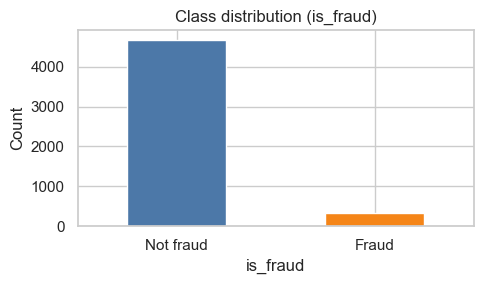

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(5, 3))
df_raw["is_fraud"].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4c78a8", "#f58518"])
ax.set_xticklabels(["Not fraud", "Fraud"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Class distribution (is_fraud)")
plt.tight_layout()
plt.show()


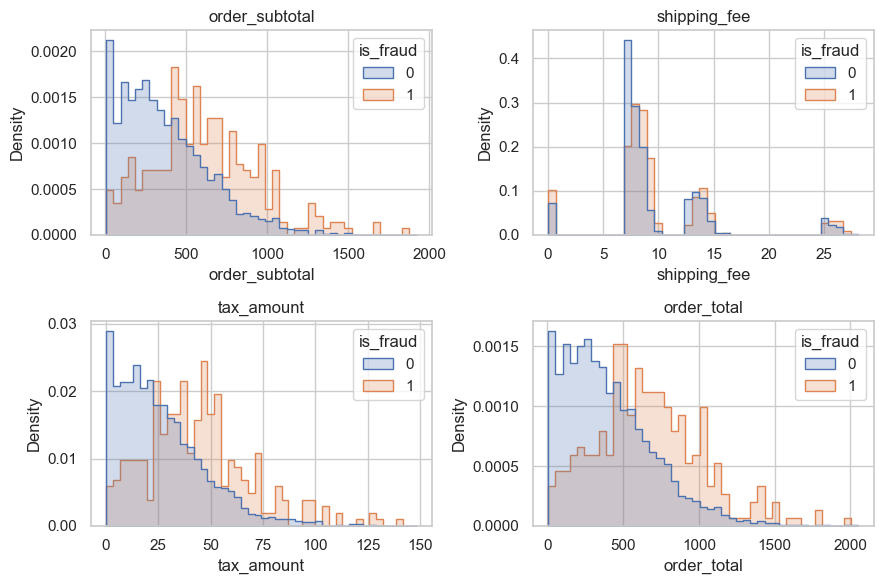

In [5]:
num_cols = ["order_subtotal", "shipping_fee", "tax_amount", "order_total"]
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
axes = axes.ravel()
for ax, c in zip(axes, num_cols):
    sns.histplot(data=df_raw, x=c, hue="is_fraud", element="step", stat="density", common_norm=False, ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()


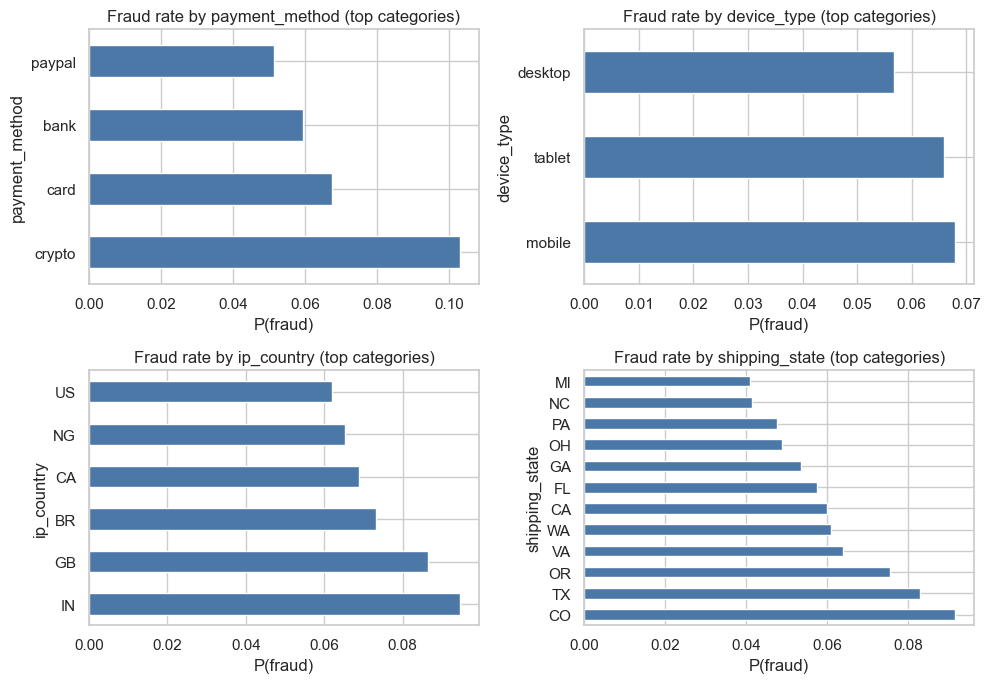

In [6]:
cat_cols = ["payment_method", "device_type", "ip_country", "shipping_state"]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()
for ax, c in zip(axes, cat_cols):
    ct = df_raw.groupby(c)["is_fraud"].mean().sort_values(ascending=False).head(12)
    ct.plot(kind="barh", ax=ax, color="#4c78a8")
    ax.set_title(f"Fraud rate by {c} (top categories)")
    ax.set_xlabel("P(fraud)")
plt.tight_layout()
plt.show()


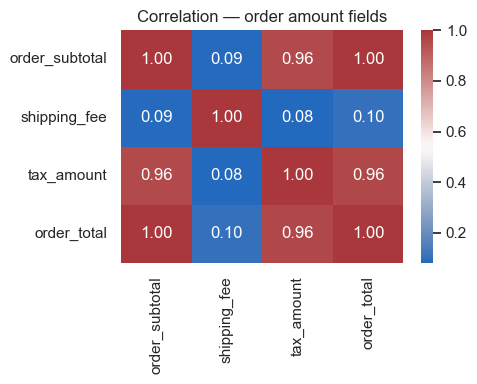

In [7]:
corr = df_raw[num_cols].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", ax=ax)
ax.set_title("Correlation — order amount fields")
plt.tight_layout()
plt.show()


## 3. Data preparation

Engineer features, stratified train/validation/test split, preprocessing inside `Pipeline` (fit on train only).


In [8]:
def add_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    dt = pd.to_datetime(out["order_datetime"])
    out["order_hour"] = dt.dt.hour.astype(float)
    out["order_dow"] = dt.dt.dayofweek.astype(float)
    out["order_month"] = dt.dt.month.astype(float)
    out["is_weekend"] = (dt.dt.dayofweek >= 5).astype(int)
    out["zip_mismatch"] = (out["billing_zip"].astype(str) != out["shipping_zip"].astype(str)).astype(int)
    cust_created = pd.to_datetime(out["customer_created_at"])
    out["tenure_days"] = (dt - cust_created).dt.days.clip(lower=0).astype(float)
    out["state_mismatch"] = (out["shipping_state"].astype(str) != out["customer_state"].astype(str)).astype(int)
    bd = pd.to_datetime(out["birthdate"])
    out["age_years"] = ((dt - bd).dt.days / 365.25).clip(0, 120).astype(float)
    return out


df = add_features(df_raw)

DROP_FROM_FEATURES = {"order_id", "order_datetime", "birthdate", "customer_created_at"}
feature_df = df.drop(columns=list(DROP_FROM_FEATURES) + ["is_fraud"], errors="ignore")
y = df["is_fraud"].values

NUMERIC_FEATURES = [
    "order_subtotal", "shipping_fee", "tax_amount", "order_total", "promo_used",
    "order_hour", "order_dow", "order_month", "is_weekend", "zip_mismatch",
    "tenure_days", "state_mismatch", "age_years", "is_active",
]
CATEGORICAL_FEATURES = [
    "billing_zip", "shipping_zip", "shipping_state", "payment_method", "device_type",
    "ip_country", "promo_code", "gender", "customer_state", "customer_segment", "loyalty_tier",
]
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in feature_df.columns]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in feature_df.columns]

X = feature_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
print("Feature matrix:", X.shape)


Feature matrix: (5000, 25)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=VAL_FRACTION_OF_TEMP, stratify=y_temp, random_state=RANDOM_STATE
)
print("Train / val / test:", X_train.shape[0], X_val.shape[0], X_test.shape[0])
for name, yt in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(name, "fraud rate", f"{yt.mean():.4f}")


Train / val / test: 3000 1000 1000
train fraud rate 0.0637
val fraud rate 0.0640
test fraud rate 0.0630


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def build_preprocessor():
    return ColumnTransformer(
        [
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                NUMERIC_FEATURES,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=50, sparse_output=False)),
                ]),
                CATEGORICAL_FEATURES,
            ),
        ]
    )


## 4. Modeling

**Baseline**: LogisticRegression (`class_weight='balanced'`).

**Ensembles**: RandomForest, GradientBoosting, HistGradientBoosting, XGBoost, LightGBM, CatBoost — same preprocessing, `RandomizedSearchCV` (5-fold stratified on **train** only).

**Imbalance**: `class_weight` / `scale_pos_weight` where applicable.


In [11]:
from scipy.stats import loguniform, randint

from sklearn.ensemble import (
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

import xgboost as xgb
import lightgbm as lgb

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False

pos = max(int(y_train.sum()), 1)
neg = len(y_train) - int(y_train.sum())
SCALE_POS_WEIGHT = neg / pos

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
n_iter_search = 12


def make_full_pipe(estimator):
    return Pipeline([("prep", build_preprocessor()), ("clf", estimator)])


def search_params(name: str):
    if name == "logreg":
        return {"clf__C": loguniform(1e-3, 1e2), "clf__solver": ["lbfgs", "saga"]}
    if name == "rf":
        return {
            "clf__n_estimators": randint(100, 400),
            "clf__max_depth": [None, 8, 16, 24],
            "clf__min_samples_leaf": randint(1, 8),
        }
    if name == "gb":
        return {
            "clf__n_estimators": randint(80, 250),
            "clf__max_depth": randint(2, 6),
            "clf__learning_rate": loguniform(0.01, 0.2),
        }
    if name == "hgb":
        return {
            "clf__learning_rate": loguniform(0.02, 0.3),
            "clf__max_depth": randint(2, 12),
            "clf__max_leaf_nodes": randint(15, 63),
            "clf__min_samples_leaf": randint(5, 40),
        }
    if name == "xgb":
        return {
            "clf__n_estimators": randint(100, 400),
            "clf__max_depth": randint(3, 10),
            "clf__learning_rate": loguniform(0.01, 0.2),
            "clf__subsample": loguniform(0.6, 1.0),
            "clf__colsample_bytree": loguniform(0.6, 1.0),
        }
    if name == "lgb":
        return {
            "clf__n_estimators": randint(100, 400),
            "clf__max_depth": randint(3, 12),
            "clf__learning_rate": loguniform(0.01, 0.2),
            "clf__num_leaves": randint(20, 80),
            "clf__subsample": loguniform(0.6, 1.0),
        }
    if name == "cat":
        return {
            "clf__depth": randint(4, 10),
            "clf__learning_rate": loguniform(0.02, 0.2),
            "clf__l2_leaf_reg": loguniform(1.0, 10.0),
        }
    return {}


models = {
    "logreg": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "rf": RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced_subsample", n_jobs=-1),
    "gb": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "hgb": HistGradientBoostingClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "xgb": xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", scale_pos_weight=SCALE_POS_WEIGHT, n_jobs=-1),
    "lgb": lgb.LGBMClassifier(random_state=RANDOM_STATE, objective="binary", class_weight="balanced", n_jobs=-1, verbose=-1),
}
if HAS_CATBOOST:
    models["cat"] = CatBoostClassifier(random_state=RANDOM_STATE, verbose=False, auto_class_weights="Balanced")

fitted = {}
for name, est in models.items():
    pipe = make_full_pipe(est)
    rs = RandomizedSearchCV(
        pipe,
        search_params(name),
        n_iter=n_iter_search,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
    )
    rs.fit(X_train, y_train)
    fitted[name] = rs
    print(name, "best CV ROC-AUC", f"{rs.best_score_:.4f}")


logreg best CV ROC-AUC 0.7635


rf best CV ROC-AUC 0.7492


gb best CV ROC-AUC 0.7536


hgb best CV ROC-AUC 0.7498


xgb best CV ROC-AUC 0.7580


lgb best CV ROC-AUC 0.7340


cat best CV ROC-AUC 0.7164


### Algorithm comparison (validation set)

All estimators scored on the **same validation split**. **Recall** uses a **0.5 probability threshold** so models are comparable (ROC-AUC is threshold-free). The table is sorted by **validation ROC-AUC** (desc), then **validation recall** (desc).


In [12]:
from sklearn.metrics import average_precision_score, recall_score, roc_auc_score


def proba(pipe, X_):
    return pipe.predict_proba(X_)[:, 1]


rows = []
for name, rs in fitted.items():
    pipe = rs.best_estimator_
    p = proba(pipe, X_val)
    pred_half = (p >= 0.5).astype(int)
    rows.append({
        "model": name,
        "cv_roc_auc_mean": rs.best_score_,
        "val_roc_auc": roc_auc_score(y_val, p),
        "val_pr_auc": average_precision_score(y_val, p),
        "val_recall_at_0.5": recall_score(y_val, pred_half, zero_division=0),
    })

results_df = (
    pd.DataFrame(rows)
    .sort_values(by=["val_roc_auc", "val_recall_at_0.5"], ascending=[False, False])
    .reset_index(drop=True)
)
results_df


,model,cv_roc_auc_mean,val_roc_auc,val_pr_auc,val_recall_at_0.5
0,logreg,0.763545,0.787560,0.188895,0.703125
1,gb,0.753626,0.786383,0.173360,0.000000
2,rf,0.749210,0.782135,0.166916,0.328125
3,hgb,0.749763,0.778512,0.162594,0.812500
4,xgb,0.757971,0.771059,0.158399,0.703125
5,lgb,0.734047,0.747997,0.150929,0.578125
6,cat,0.716408,0.729834,0.131488,0.171875


## 5. Evaluation

Select the best model by **validation ROC-AUC**, tune the decision threshold on validation, then report on the **test** set. Permutation importance on validation for interpretability.


In [13]:
val_scores = {}
for name, rs in fitted.items():
    p = proba(rs.best_estimator_, X_val)
    val_scores[name] = {
        "roc_auc": roc_auc_score(y_val, p),
        "pr_auc": average_precision_score(y_val, p),
    }

val_df = pd.DataFrame(val_scores).T.sort_values("roc_auc", ascending=False)
print("Validation ranking (ROC-AUC):")
print(val_df)

best_name = val_df.index[0]
best_pipe = fitted[best_name].best_estimator_
print("Best model:", best_name)

val_prob = proba(best_pipe, X_val)
test_prob = proba(best_pipe, X_test)


Validation ranking (ROC-AUC):
         roc_auc    pr_auc
logreg  0.787560  0.188895
gb      0.786383  0.173360
rf      0.782135  0.166916
hgb     0.778512  0.162594
xgb     0.771059  0.158399
lgb     0.747997  0.150929
cat     0.729834  0.131488
Best model: logreg


In [14]:
from sklearn.metrics import precision_recall_curve, roc_curve


def tune_threshold(y_true, scores, min_precision=0.15):
    prec, rec, thr = precision_recall_curve(y_true, scores)
    best_t, best_rec = 0.5, -1.0
    for i in range(len(thr)):
        p, r = prec[i + 1], rec[i + 1]
        t = thr[i]
        if p >= min_precision and r > best_rec:
            best_rec = r
            best_t = t
    if best_rec < 0:
        fpr, tpr, thresholds = roc_curve(y_true, scores)
        j = tpr - fpr
        ix = int(np.argmax(j))
        best_t = float(thresholds[ix]) if ix < len(thresholds) else 0.5
    return float(best_t)


THRESHOLD = tune_threshold(y_val, val_prob)
print("Operating threshold (validation):", round(THRESHOLD, 4))


Operating threshold (validation): 0.5299


--- Validation ---
ROC-AUC: 0.7876  PR-AUC: 0.1889
              precision    recall  f1-score   support

           0     0.9651    0.7692    0.8561       936
           1     0.1496    0.5938    0.2390        64

    accuracy                         0.7580      1000
   macro avg     0.5574    0.6815    0.5476      1000
weighted avg     0.9130    0.7580    0.8166      1000

--- Test ---
ROC-AUC: 0.7757  PR-AUC: 0.1698
              precision    recall  f1-score   support

           0     0.9696    0.7823    0.8659       937
           1     0.1639    0.6349    0.2606        63

    accuracy                         0.7730      1000
   macro avg     0.5668    0.7086    0.5633      1000
weighted avg     0.9188    0.7730    0.8278      1000



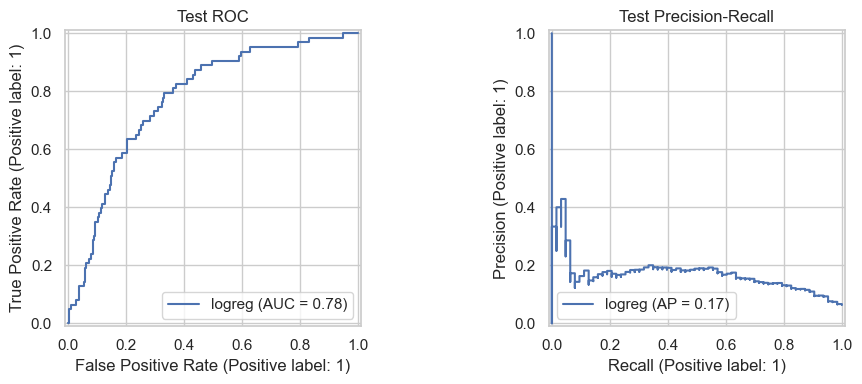

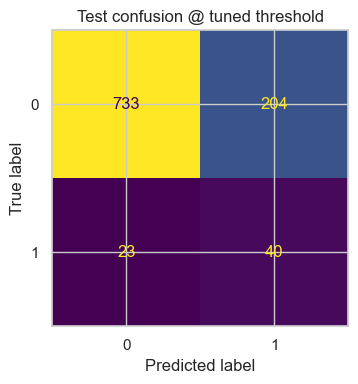

In [15]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    classification_report,
)


def report_split(y_true, scores, name):
    auc = roc_auc_score(y_true, scores)
    pr = average_precision_score(y_true, scores)
    pred = (scores >= THRESHOLD).astype(int)
    print(f"--- {name} ---")
    print(f"ROC-AUC: {auc:.4f}  PR-AUC: {pr:.4f}")
    print(classification_report(y_true, pred, digits=4))


report_split(y_val, val_prob, "Validation")
report_split(y_test, test_prob, "Test")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
RocCurveDisplay.from_predictions(y_test, test_prob, ax=axes[0], name=best_name)
axes[0].set_title("Test ROC")
PrecisionRecallDisplay.from_predictions(y_test, test_prob, ax=axes[1], name=best_name)
axes[1].set_title("Test Precision-Recall")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(y_test, (test_prob >= THRESHOLD).astype(int), ax=ax, colorbar=False)
ax.set_title("Test confusion @ tuned threshold")
plt.tight_layout()
plt.show()


Permutation importance (top 15):
tenure_days       0.026327
order_subtotal    0.021095
order_total       0.020097
tax_amount        0.011215
customer_state    0.007497
age_years         0.006041
zip_mismatch      0.004370
shipping_state    0.003400
billing_zip       0.002823
order_month       0.002229
loyalty_tier      0.001537
shipping_zip      0.001356
state_mismatch    0.001352
payment_method    0.000795
promo_code        0.000230
dtype: float64


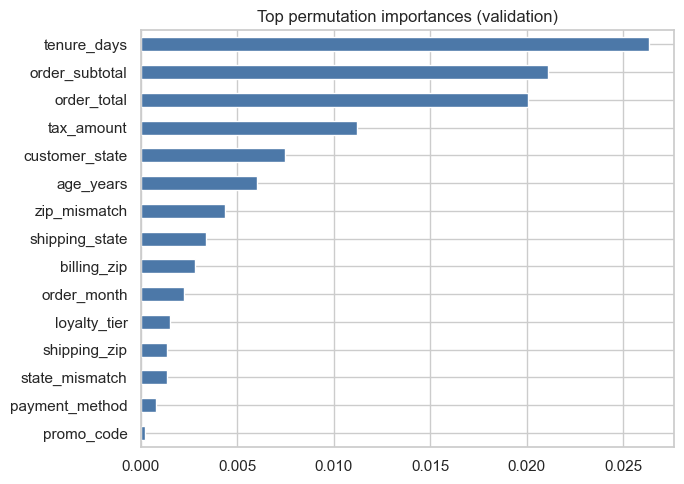

In [16]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_pipe, X_val, y_val, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1, scoring="roc_auc"
)
imp = pd.Series(result.importances_mean, index=X_val.columns).sort_values(ascending=False)
print("Permutation importance (top 15):")
print(imp.head(15))

fig, ax = plt.subplots(figsize=(7, 5))
imp.head(15).sort_values().plot(kind="barh", ax=ax, color="#4c78a8")
ax.set_title("Top permutation importances (validation)")
plt.tight_layout()
plt.show()


## 6. Deployment

Refit on **train + validation**, save `fraud_model.joblib`, `threshold.json`, `feature_order.json`. Use **`inference.py`** for Vercel Python (same JSON contract as `predict_fraud` below).


In [17]:
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val])

final_pipe = fitted[best_name].best_estimator_
final_pipe.fit(X_trainval, y_trainval)

MODEL_PATH = ARTIFACT_DIR / "fraud_model.joblib"
THRESHOLD_PATH = ARTIFACT_DIR / "threshold.json"
FEATURE_ORDER_PATH = ARTIFACT_DIR / "feature_order.json"

joblib.dump(final_pipe, MODEL_PATH)
with open(THRESHOLD_PATH, "w", encoding="utf-8") as f:
    json.dump({"threshold": THRESHOLD, "best_model": best_name}, f, indent=2)

feature_order = {
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "all_columns": list(X.columns),
}
with open(FEATURE_ORDER_PATH, "w", encoding="utf-8") as f:
    json.dump(feature_order, f, indent=2)

print("Saved:", MODEL_PATH, THRESHOLD_PATH, FEATURE_ORDER_PATH)
print("joblib size (MB):", round(MODEL_PATH.stat().st_size / 1e6, 2))


Saved: /Users/nickreeves/Downloads/Deployment455/fraud_model.joblib /Users/nickreeves/Downloads/Deployment455/threshold.json /Users/nickreeves/Downloads/Deployment455/feature_order.json
joblib size (MB): 0.03


In [18]:
def predict_fraud(payload: dict, model_path=None, threshold_path=None) -> dict:
    model_path = model_path or ARTIFACT_DIR / "fraud_model.joblib"
    threshold_path = threshold_path or ARTIFACT_DIR / "threshold.json"
    pipe = joblib.load(model_path)
    with open(threshold_path, encoding="utf-8") as f:
        thr_data = json.load(f)
    thr = float(thr_data["threshold"])
    row = pd.DataFrame([payload])
    row = add_features(row)
    row = row[X.columns]
    prob = float(pipe.predict_proba(row)[0, 1])
    return {"fraud_probability": prob, "is_fraud": bool(prob >= thr), "threshold": thr}


demo = df_raw.iloc[0].to_dict()
demo_payload = {
    "order_datetime": demo["order_datetime"],
    "billing_zip": demo["billing_zip"],
    "shipping_zip": demo["shipping_zip"],
    "shipping_state": demo["shipping_state"],
    "payment_method": demo["payment_method"],
    "device_type": demo["device_type"],
    "ip_country": demo["ip_country"],
    "promo_used": demo["promo_used"],
    "promo_code": demo["promo_code"],
    "order_subtotal": demo["order_subtotal"],
    "shipping_fee": demo["shipping_fee"],
    "tax_amount": demo["tax_amount"],
    "order_total": demo["order_total"],
    "gender": demo["gender"],
    "birthdate": demo["birthdate"],
    "customer_created_at": demo["customer_created_at"],
    "customer_state": demo["customer_state"],
    "customer_segment": demo["customer_segment"],
    "loyalty_tier": demo["loyalty_tier"],
    "is_active": demo["is_active"],
}
print(predict_fraud(demo_payload))


{'fraud_probability': 0.6545252306331075, 'is_fraud': True, 'threshold': 0.529881713370354}
